# Task 8 — The Executive Insight

## PlaceMux Phase 1 Industry Immersion

### Objective
Convert the baseline analysis into a concise executive insight
with key metrics, important movements, and one recommended action.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("/content/Cleaned_Sales_Data (1).csv")

df.head()

,order_id,order_date,customer_id,customer_name,city,category,product,quantity,unit_price,discount_pct,payment_method,sales_channel,status
0,O0001,2026-02-05,C011,Vikas Tiwari,Ujjain,ELECTRONICS,Wireless Mouse,6.0,900.0,0,cash,online,completed
1,O0002,2026-04-25,C004,Neha Singh,Jabalpur,Electronics,Headphones,1.0,1400.0,15,cod,offline,completed
2,O0003,2026-06-04,C006,Sneha Gupta,Bhopal,electronics,Wireless Mouse,1.0,700.0,20,upi,Offline,Pending
3,O0004,2026-02-28,C005,rohit patel,Ujjain,Grocery,Cooking Oil,1.0,160.0,0,upi,Online,cancelled
4,O0005,2026-12-06,C003,AMIT KHAN,Rewa,Grocery,Rice Bag,5.0,950.0,5,cash,Online,Cancelled


In [2]:
print("Dataset Shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset Shape: (120, 13)

Columns:
['order_id', 'order_date', 'customer_id', 'customer_name', 'city', 'category', 'product', 'quantity', 'unit_price', 'discount_pct', 'payment_method', 'sales_channel', 'status']


In [3]:
# STEP 2 — Data Verification

print("Missing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

print("\nData Types:")
print(df.dtypes)

Missing Values:
order_id          0
order_date        0
customer_id       0
customer_name     0
city              0
category          0
product           0
quantity          0
unit_price        0
discount_pct      0
payment_method    0
sales_channel     0
status            0
dtype: int64

Duplicate Rows: 0

Data Types:
order_id           object
order_date         object
customer_id        object
customer_name      object
city               object
category           object
product            object
quantity          float64
unit_price        float64
discount_pct        int64
payment_method     object
sales_channel      object
status             object
dtype: object


In [4]:
# Check unique values in important categorical columns

print("Categories:")
print(df["category"].unique())

print("\nSales Channels:")
print(df["sales_channel"].unique())

print("\nOrder Status:")
print(df["status"].unique())

print("\nPayment Methods:")
print(df["payment_method"].unique())

Categories:
[' ELECTRONICS ' 'Electronics' 'electronics' 'Grocery' 'home' ' CLOTHING '
 ' HOME ' 'clothing' 'Clothing' 'Home' ' GROCERY ' 'grocery']

Sales Channels:
['online' 'offline' ' Offline' 'Online' 'ONLINE']

Order Status:
['completed' ' Pending' 'cancelled' 'Cancelled' 'Completed' 'pending']

Payment Methods:
['cash' 'cod' 'upi' 'UPI' 'COD' 'card' 'Card' ' UPI ' 'Cash']


In [5]:
df["payment_method"] = df["payment_method"].str.strip().str.lower()

df["sales_channel"] = df["sales_channel"].str.strip().str.lower()

df["status"] = df["status"].str.strip().str.lower()

In [ ]:
# Standardize category names

df["category"] = df["category"].str.strip().str.lower()

print(df["category"].value_counts())

category
grocery        36
electronics    29
clothing       28
home           27
Name: count, dtype: int64


In [6]:
print("Categories:")
print(df["category"].value_counts())

print("\nPayment Methods:")
print(df["payment_method"].value_counts())

print("\nSales Channels:")
print(df["sales_channel"].value_counts())

print("\nStatus:")
print(df["status"].value_counts())

Categories:
category
Grocery          23
 ELECTRONICS     14
clothing         13
Home             10
Clothing          9
home              9
 HOME             8
electronics       8
Electronics       7
 GROCERY          7
 CLOTHING         6
grocery           6
Name: count, dtype: int64

Payment Methods:
payment_method
upi     46
cod     28
cash    26
card    20
Name: count, dtype: int64

Sales Channels:
sales_channel
online     74
offline    46
Name: count, dtype: int64

Status:
status
completed    45
cancelled    39
pending      36
Name: count, dtype: int64


In [7]:
print("Missing Values:", df.isnull().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())

Missing Values: 0
Duplicate Rows: 0


In [8]:
# STEP 3 — Explore Business Metrics

# Convert order_date to datetime
df["order_date"] = pd.to_datetime(df["order_date"])

# Basic business metrics
total_orders = df["order_id"].nunique()
total_quantity = df["quantity"].sum()
avg_quantity = df["quantity"].mean()
avg_discount = df["discount_pct"].mean()

print("Total Orders:", total_orders)
print("Total Quantity Sold:", total_quantity)
print("Average Quantity per Order:", round(avg_quantity, 2))
print("Average Discount %:", round(avg_discount, 2))

Total Orders: 120
Total Quantity Sold: 416.0
Average Quantity per Order: 3.47
Average Discount %: 9.38


In [9]:
# Calculate sales values

df["gross_sales"] = df["quantity"] * df["unit_price"]

df["discount_amount"] = (
    df["gross_sales"] * df["discount_pct"] / 100
)

df["net_sales"] = (
    df["gross_sales"] - df["discount_amount"]
)

print("Total Gross Sales:", round(df["gross_sales"].sum(), 2))
print("Total Discount Amount:", round(df["discount_amount"].sum(), 2))
print("Total Net Sales:", round(df["net_sales"].sum(), 2))

Total Gross Sales: 354560.0
Total Discount Amount: 30990.5
Total Net Sales: 323569.5


In [10]:
category_sales = (
    df.groupby("category")["net_sales"]
    .sum()
    .sort_values(ascending=False)
)

print(category_sales)

category
 ELECTRONICS     43802.5
clothing         42615.0
Grocery          41353.0
Home             39175.0
Clothing         37625.0
 CLOTHING        24985.0
electronics      24547.5
home             21587.5
 HOME            17642.5
Electronics      16050.0
grocery           8215.0
 GROCERY          5971.5
Name: net_sales, dtype: float64


In [11]:
channel_sales = (
    df.groupby("sales_channel")["net_sales"]
    .sum()
    .sort_values(ascending=False)
)

print(channel_sales)

sales_channel
online     205802.5
offline    117767.0
Name: net_sales, dtype: float64


In [12]:
status_sales = (
    df.groupby("status")["net_sales"]
    .sum()
    .sort_values(ascending=False)
)

print(status_sales)

status
completed    112678.5
pending      110266.0
cancelled    100625.0
Name: net_sales, dtype: float64


In [13]:
# STEP 4 — Monthly Net Sales Trend

df["month"] = df["order_date"].dt.to_period("M")

monthly_sales = (
    df.groupby("month")["net_sales"]
    .sum()
)

print(monthly_sales)

month
2026-01    56831.0
2026-02    44985.0
2026-03    45811.0
2026-04    52536.5
2026-05    56742.5
2026-06    47001.0
2026-08     2090.0
2026-09      595.0
2026-10     5400.0
2026-12    11577.5
Freq: M, Name: net_sales, dtype: float64


In [14]:
# Monthly Average Benchmark

monthly_average = monthly_sales.mean()

print("Monthly Average Net Sales:", round(monthly_average, 2))

Monthly Average Net Sales: 32356.95


In [15]:
# Compare Monthly Sales with Benchmark

monthly_comparison = pd.DataFrame({
    "Net Sales": monthly_sales,
    "Benchmark": monthly_average
})

monthly_comparison["Difference"] = (
    monthly_comparison["Net Sales"] - monthly_comparison["Benchmark"]
)

monthly_comparison["Performance"] = np.where(
    monthly_comparison["Net Sales"] >= monthly_average,
    "Above Benchmark",
    "Below Benchmark"
)

print(monthly_comparison)

         Net Sales  Benchmark  Difference      Performance
month                                                     
2026-01    56831.0   32356.95    24474.05  Above Benchmark
2026-02    44985.0   32356.95    12628.05  Above Benchmark
2026-03    45811.0   32356.95    13454.05  Above Benchmark
2026-04    52536.5   32356.95    20179.55  Above Benchmark
2026-05    56742.5   32356.95    24385.55  Above Benchmark
2026-06    47001.0   32356.95    14644.05  Above Benchmark
2026-08     2090.0   32356.95   -30266.95  Below Benchmark
2026-09      595.0   32356.95   -31761.95  Below Benchmark
2026-10     5400.0   32356.95   -26956.95  Below Benchmark
2026-12    11577.5   32356.95   -20779.45  Below Benchmark


In [16]:
# STEP 5 — Executive Metric Summary

executive_metrics = {
    "Total Net Sales": df["net_sales"].sum(),
    "Total Orders": df["order_id"].nunique(),
    "Average Discount %": df["discount_pct"].mean(),
    "Top Category": df.groupby("category")["net_sales"].sum().idxmax(),
    "Top Sales Channel": df.groupby("sales_channel")["net_sales"].sum().idxmax()
}

for metric, value in executive_metrics.items():
    print(f"{metric}: {value}")

Total Net Sales: 323569.5
Total Orders: 120
Average Discount %: 9.375
Top Category:  ELECTRONICS 
Top Sales Channel: online


In [17]:
# Category contribution %

category_summary = (
    df.groupby("category")["net_sales"]
    .sum()
    .sort_values(ascending=False)
)

category_share = (category_summary / df["net_sales"].sum()) * 100

print("Category Sales Share (%):")
print(category_share.round(2))

Category Sales Share (%):
category
 ELECTRONICS     13.54
clothing         13.17
Grocery          12.78
Home             12.11
Clothing         11.63
 CLOTHING         7.72
electronics       7.59
home              6.67
 HOME             5.45
Electronics       4.96
grocery           2.54
 GROCERY          1.85
Name: net_sales, dtype: float64


In [18]:
# Sales channel contribution %

channel_summary = (
    df.groupby("sales_channel")["net_sales"]
    .sum()
    .sort_values(ascending=False)
)

channel_share = (channel_summary / df["net_sales"].sum()) * 100

print("Sales Channel Share (%):")
print(channel_share.round(2))

Sales Channel Share (%):
sales_channel
online     63.6
offline    36.4
Name: net_sales, dtype: float64


In [19]:
# STEP 6 — Identify the Most Important Movement

highest_month = monthly_sales.idxmax()
highest_value = monthly_sales.max()

lowest_month = monthly_sales.idxmin()
lowest_value = monthly_sales.min()

print("Highest Sales Month:", highest_month)
print("Highest Monthly Sales:", highest_value)

print("\nLowest Sales Month:", lowest_month)
print("Lowest Monthly Sales:", lowest_value)

print("\nMonthly Benchmark:", monthly_average)

Highest Sales Month: 2026-01
Highest Monthly Sales: 56831.0

Lowest Sales Month: 2026-09
Lowest Monthly Sales: 595.0

Monthly Benchmark: 32356.95


In [20]:
# Change from highest month to lowest month

percentage_change = (
    (lowest_value - highest_value) / highest_value
) * 100

print(
    "Change from Highest to Lowest Month:",
    round(percentage_change, 2),
    "%"
)

Change from Highest to Lowest Month: -98.95 %


In [21]:
print("Highest Month:", highest_month)
print("Highest Sales:", round(highest_value, 2))

print("Lowest Month:", lowest_month)
print("Lowest Sales:", round(lowest_value, 2))

print("Change:", round(percentage_change, 2), "%")

Highest Month: 2026-01
Highest Sales: 56831.0
Lowest Month: 2026-09
Lowest Sales: 595.0
Change: -98.95 %


In [22]:
# STEP 7 — Prepare Executive Action Inputs

top_category = category_summary.idxmax()
top_category_sales = category_summary.max()
top_category_share = category_share.max()

top_channel = channel_summary.idxmax()
top_channel_sales = channel_summary.max()
top_channel_share = channel_share.max()

print("Top Category:", top_category)
print("Top Category Sales:", round(top_category_sales, 2))
print("Top Category Share:", round(top_category_share, 2), "%")

print("\nTop Sales Channel:", top_channel)
print("Top Channel Sales:", round(top_channel_sales, 2))
print("Top Channel Share:", round(top_channel_share, 2), "%")

print("\nAverage Discount:", round(df["discount_pct"].mean(), 2), "%")

Top Category:  ELECTRONICS 
Top Category Sales: 43802.5
Top Category Share: 13.54 %

Top Sales Channel: online
Top Channel Sales: 205802.5
Top Channel Share: 63.6 %

Average Discount: 9.38 %


In [23]:
# STEP 7A — Final Category & Channel Verification

final_category_sales = (
    df.groupby("category")["net_sales"]
      .sum()
      .sort_values(ascending=False)
)

final_channel_sales = (
    df.groupby("sales_channel")["net_sales"]
      .sum()
      .sort_values(ascending=False)
)

print("FINAL CATEGORY SALES")
print(final_category_sales)

print("\nFINAL CHANNEL SALES")
print(final_channel_sales)

print("\nTOTAL NET SALES:", round(df["net_sales"].sum(), 2))

FINAL CATEGORY SALES
category
 ELECTRONICS     43802.5
clothing         42615.0
Grocery          41353.0
Home             39175.0
Clothing         37625.0
 CLOTHING        24985.0
electronics      24547.5
home             21587.5
 HOME            17642.5
Electronics      16050.0
grocery           8215.0
 GROCERY          5971.5
Name: net_sales, dtype: float64

FINAL CHANNEL SALES
sales_channel
online     205802.5
offline    117767.0
Name: net_sales, dtype: float64

TOTAL NET SALES: 323569.5


In [24]:
# Normalize category names
df["category"] = df["category"].str.strip().str.lower()

# Recalculate category-wise net sales
final_category_sales = (
    df.groupby("category")["net_sales"]
      .sum()
      .sort_values(ascending=False)
)

print("FINAL CATEGORY SALES")
print(final_category_sales)

print("\nTOTAL CATEGORY SALES:", round(final_category_sales.sum(), 2))

FINAL CATEGORY SALES
category
clothing       105225.0
electronics     84400.0
home            78405.0
grocery         55539.5
Name: net_sales, dtype: float64

TOTAL CATEGORY SALES: 323569.5


In [25]:
# STEP 8 — Executive Benchmarks

total_net_sales = df["net_sales"].sum()

top_category_sales = final_category_sales.iloc[0]
top_category = final_category_sales.index[0]
top_category_share = (top_category_sales / total_net_sales) * 100

online_sales = final_channel_sales["online"]
online_share = (online_sales / total_net_sales) * 100

avg_discount = df["discount_pct"].mean()

print("Total Net Sales:", round(total_net_sales, 2))
print("Top Category:", top_category.title())
print("Top Category Sales:", round(top_category_sales, 2))
print("Top Category Share:", round(top_category_share, 2), "%")
print("Online Sales:", round(online_sales, 2))
print("Online Share:", round(online_share, 2), "%")
print("Average Discount:", round(avg_discount, 2), "%")

Total Net Sales: 323569.5
Top Category: Clothing
Top Category Sales: 105225.0
Top Category Share: 32.52 %
Online Sales: 205802.5
Online Share: 63.6 %
Average Discount: 9.38 %


In [26]:

# STEP 9 — Monthly Sales Trend & Benchmark

# Recalculate monthly sales
monthly_sales = (
    df.groupby(df["order_date"].dt.to_period("M"))["net_sales"]
      .sum()
      .sort_index()
)

# Calculate benchmark using available months
monthly_benchmark = monthly_sales.mean()

print("MONTHLY NET SALES")
print(monthly_sales)

print("\nAverage Monthly Sales Benchmark:",
      round(monthly_benchmark, 2))

print("\nHighest Sales Month:",
      monthly_sales.idxmax(),
      round(monthly_sales.max(), 2))

print("\nLowest Sales Month:",
      monthly_sales.idxmin(),
      round(monthly_sales.min(), 2))

# Identify missing months
all_months = monthly_sales.index.to_timestamp()
complete_range = pd.date_range(
    all_months.min(),
    all_months.max(),
    freq="MS"
)

missing_months = complete_range.difference(all_months)

print("\nMissing Months:",
      missing_months.strftime("%Y-%m").tolist())

MONTHLY NET SALES
order_date
2026-01    56831.0
2026-02    44985.0
2026-03    45811.0
2026-04    52536.5
2026-05    56742.5
2026-06    47001.0
2026-08     2090.0
2026-09      595.0
2026-10     5400.0
2026-12    11577.5
Freq: M, Name: net_sales, dtype: float64

Average Monthly Sales Benchmark: 32356.95

Highest Sales Month: 2026-01 56831.0

Lowest Sales Month: 2026-09 595.0

Missing Months: ['2026-07', '2026-11']


In [27]:
# STEP 10 — Key Movement

highest_month_sales = monthly_sales.max()
lowest_month_sales = monthly_sales.min()

drop_from_highest = (
    (highest_month_sales - lowest_month_sales)
    / highest_month_sales
) * 100

benchmark_gap = (
    (lowest_month_sales - monthly_benchmark)
    / monthly_benchmark
) * 100

print("Highest Monthly Sales:", round(highest_month_sales, 2))
print("Lowest Monthly Sales:", round(lowest_month_sales, 2))

print("Drop from Highest to Lowest:",
      round(drop_from_highest, 2), "%")

print("Lowest Month vs Average Benchmark:",
      round(benchmark_gap, 2), "%")

Highest Monthly Sales: 56831.0
Lowest Monthly Sales: 595.0
Drop from Highest to Lowest: 98.95 %
Lowest Month vs Average Benchmark: -98.16 %


Most important movement:
Monthly net sales fell from the highest observed month of ₹56,831 to the lowest observed month of ₹595, a 98.95% decline.

Benchmark:
September's ₹595 is 98.16% below the available-month average of ₹32,356.95.

Important caveat: July and November are missing, so this should be presented as an observed movement in the available data, not as a confirmed continuous decline. This aligns with Task 8's requirement to surface the important movement without hiding data issues

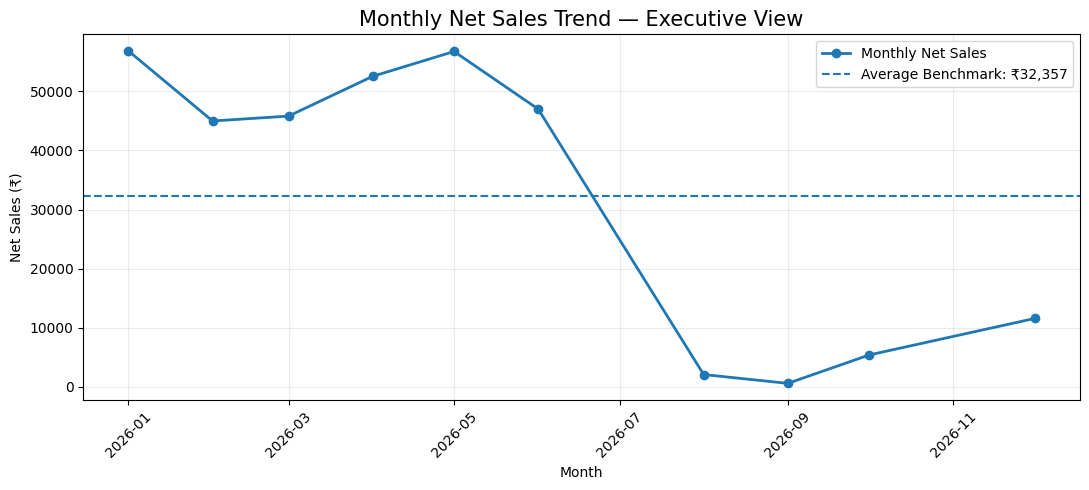

In [28]:
import matplotlib.pyplot as plt

# Convert Period to timestamp for plotting
plot_months = monthly_sales.index.to_timestamp()

plt.figure(figsize=(11, 5))

plt.plot(
    plot_months,
    monthly_sales.values,
    marker="o",
    linewidth=2,
    label="Monthly Net Sales"
)

plt.axhline(
    monthly_benchmark,
    linestyle="--",
    linewidth=1.5,
    label=f"Average Benchmark: ₹{monthly_benchmark:,.0f}"
)

plt.title("Monthly Net Sales Trend — Executive View", fontsize=15)
plt.xlabel("Month")
plt.ylabel("Net Sales (₹)")
plt.xticks(rotation=45)
plt.legend()
plt.grid(alpha=0.25)
plt.tight_layout()

plt.show()

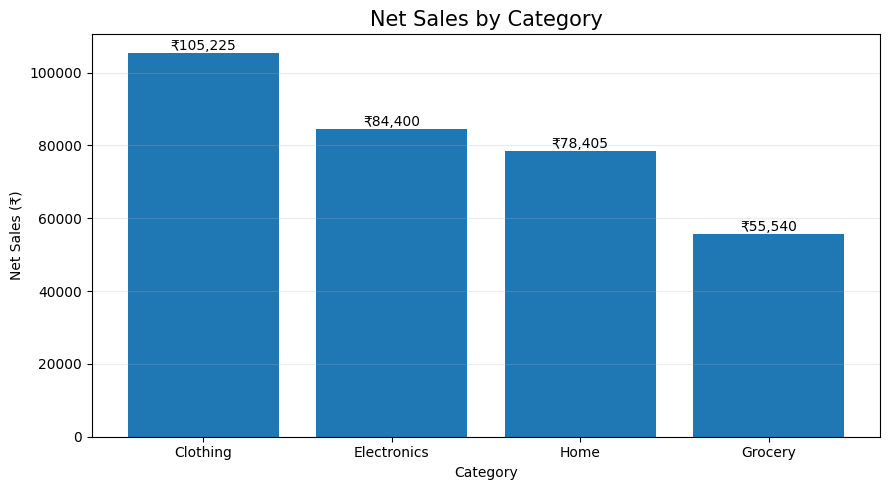

In [29]:
# STEP 12 — Category Contribution Chart

category_sales = (
    df.groupby("category")["net_sales"]
      .sum()
      .sort_values(ascending=False)
)

plt.figure(figsize=(9, 5))

bars = plt.bar(
    category_sales.index.str.title(),
    category_sales.values
)

plt.title("Net Sales by Category", fontsize=15)
plt.xlabel("Category")
plt.ylabel("Net Sales (₹)")
plt.xticks(rotation=0)
plt.grid(axis="y", alpha=0.25)

# Add values on bars
for bar, value in zip(bars, category_sales.values):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height(),
        f"₹{value:,.0f}",
        ha="center",
        va="bottom",
        fontsize=10
    )

plt.tight_layout()
plt.show()

🔴 Key Insight

Net sales show a very large drop in the available monthly data, with September at ₹595 versus an available-month average of ₹32,356.95.

⚠️ Data caveat

July and November are missing, so we should not claim a continuous month-by-month decline.

🎯 Recommended Action

Investigate the low-sales months and validate monthly data completeness before making pricing, inventory, or marketing decisions.

Expected Impact
Identify whether the September low is a real business movement or a data-coverage issue.
Prevent leadership from making decisions using incomplete monthly information.
Once validated, enable targeted action around the actual sales driver.

# Executive Insight Summary

## Business Snapshot

| Metric | Current Value | Benchmark / Context | So What? |
|---|---:|---:|---|
| Total Net Sales | ₹3,23,569.50 | Overall dataset | Establishes the current sales base |
| Top Category | Clothing — ₹1,05,225 | 32.52% of total sales | Clothing is the largest category contributor |
| Online Sales | ₹2,05,802.50 | 63.60% of total sales | Online is the dominant sales channel |
| Average Discount | 9.38% | Dataset average | Indicates the typical discount level applied |
| Monthly Sales | September: ₹595 | Avg. available month: ₹32,356.95 | September is substantially below the available-month benchmark |

## Most Important Movement

Monthly net sales moved from a high of ₹56,831 in January to a low of ₹595 in September — a 98.95% difference.

July and November have no recorded monthly sales in the dataset, so the movement should be treated as an observed pattern in the available data rather than a confirmed continuous decline.

## Recommended Action

Validate monthly data completeness and investigate the low-sales months before making major pricing, inventory, or marketing decisions.

## Expected Impact

This will distinguish a genuine sales decline from a data-coverage issue and help leadership base the next business action on reliable evidence.

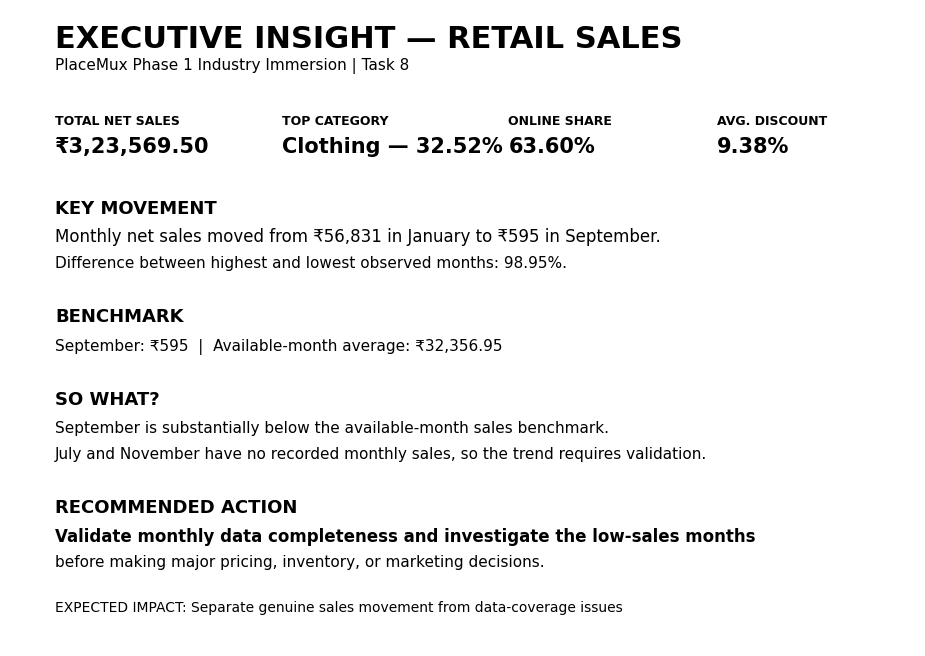

✅ Executive Insight PNG created successfully.


In [32]:
# STEP 15B — Fixed One-Page Executive Insight

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(11.69, 8.27))

# Remove axes
ax.axis("off")

# Title
ax.text(
    0.05, 0.94,
    "EXECUTIVE INSIGHT — RETAIL SALES",
    fontsize=22,
    fontweight="bold",
    transform=ax.transAxes
)

ax.text(
    0.05, 0.905,
    "PlaceMux Phase 1 Industry Immersion | Task 8",
    fontsize=11,
    transform=ax.transAxes
)

# KPI section
ax.text(0.05, 0.82, "TOTAL NET SALES", fontsize=9,
        fontweight="bold", transform=ax.transAxes)
ax.text(0.05, 0.775, "₹3,23,569.50", fontsize=15,
        fontweight="bold", transform=ax.transAxes)

ax.text(0.30, 0.82, "TOP CATEGORY", fontsize=9,
        fontweight="bold", transform=ax.transAxes)
ax.text(0.30, 0.775, "Clothing — 32.52%", fontsize=15,
        fontweight="bold", transform=ax.transAxes)

ax.text(0.55, 0.82, "ONLINE SHARE", fontsize=9,
        fontweight="bold", transform=ax.transAxes)
ax.text(0.55, 0.775, "63.60%", fontsize=15,
        fontweight="bold", transform=ax.transAxes)

ax.text(0.78, 0.82, "AVG. DISCOUNT", fontsize=9,
        fontweight="bold", transform=ax.transAxes)
ax.text(0.78, 0.775, "9.38%", fontsize=15,
        fontweight="bold", transform=ax.transAxes)

# Key movement
ax.text(
    0.05, 0.68,
    "KEY MOVEMENT",
    fontsize=13,
    fontweight="bold",
    transform=ax.transAxes
)

ax.text(
    0.05, 0.635,
    "Monthly net sales moved from ₹56,831 in January to ₹595 in September.",
    fontsize=12,
    transform=ax.transAxes
)

ax.text(
    0.05, 0.595,
    "Difference between highest and lowest observed months: 98.95%.",
    fontsize=11,
    transform=ax.transAxes
)

# Benchmark
ax.text(
    0.05, 0.51,
    "BENCHMARK",
    fontsize=13,
    fontweight="bold",
    transform=ax.transAxes
)

ax.text(
    0.05, 0.465,
    "September: ₹595  |  Available-month average: ₹32,356.95",
    fontsize=11,
    transform=ax.transAxes
)

# So what
ax.text(
    0.05, 0.38,
    "SO WHAT?",
    fontsize=13,
    fontweight="bold",
    transform=ax.transAxes
)

ax.text(
    0.05, 0.335,
    "September is substantially below the available-month sales benchmark.",
    fontsize=11,
    transform=ax.transAxes
)

ax.text(
    0.05, 0.295,
    "July and November have no recorded monthly sales, so the trend requires validation.",
    fontsize=11,
    transform=ax.transAxes
)

# Recommendation
ax.text(
    0.05, 0.21,
    "RECOMMENDED ACTION",
    fontsize=13,
    fontweight="bold",
    transform=ax.transAxes
)

ax.text(
    0.05, 0.165,
    "Validate monthly data completeness and investigate the low-sales months",
    fontsize=12,
    fontweight="bold",
    transform=ax.transAxes
)

ax.text(
    0.05, 0.125,
    "before making major pricing, inventory, or marketing decisions.",
    fontsize=11,
    transform=ax.transAxes
)

# Expected impact
ax.text(
    0.05, 0.055,
    "EXPECTED IMPACT: Separate genuine sales movement from data-coverage issues",
    fontsize=10,
    transform=ax.transAxes
)

plt.savefig(
    "Task_8_Executive_Insight.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("✅ Executive Insight PNG created successfully.")